# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

From the given documentation of the UCI dataset and the research paper on the "A Data-Driven Approach to Predict the Success of Bank Telemarketing," (Moro, Cortez, and Rita, 2014), this data can be seen as a collection of 5 different campaigns carried out by the Portuguese retail banking company.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [37]:
import pandas as pd

In [38]:
df = pd.read_csv('bank-additional-full.csv', sep = ';')

In [39]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [41]:
df['y_binary'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [42]:
df.select_dtypes(include = 'object').nunique()

,0
job,12
marital,4
education,8
default,3
housing,3
loan,3
contact,2
month,10
day_of_week,5
poutcome,3


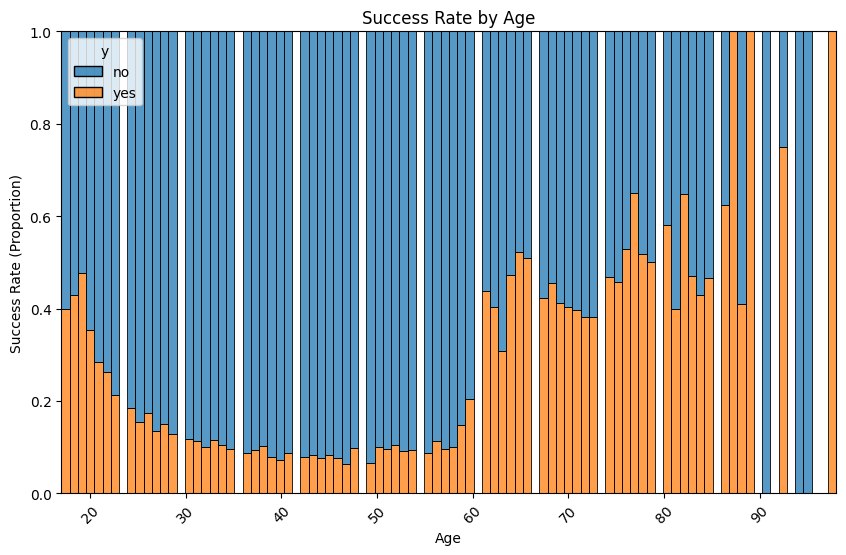

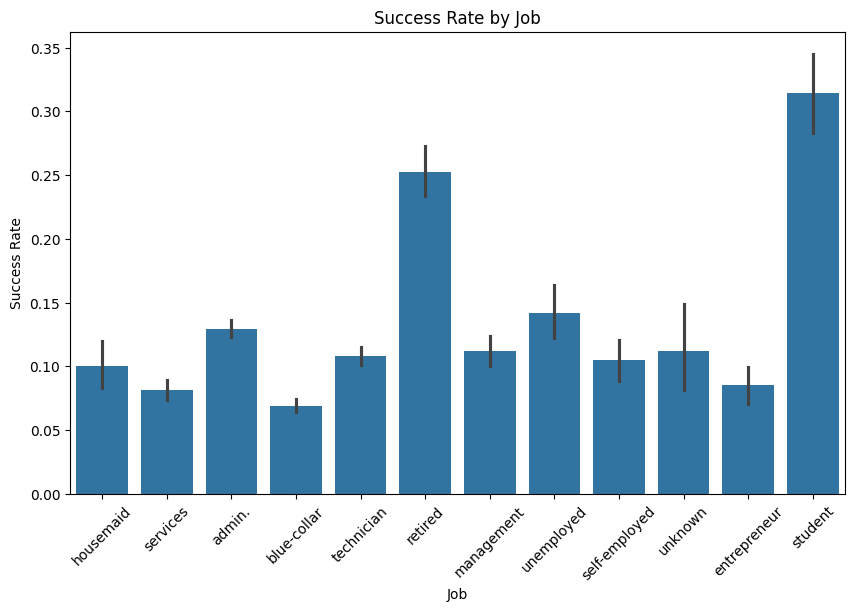

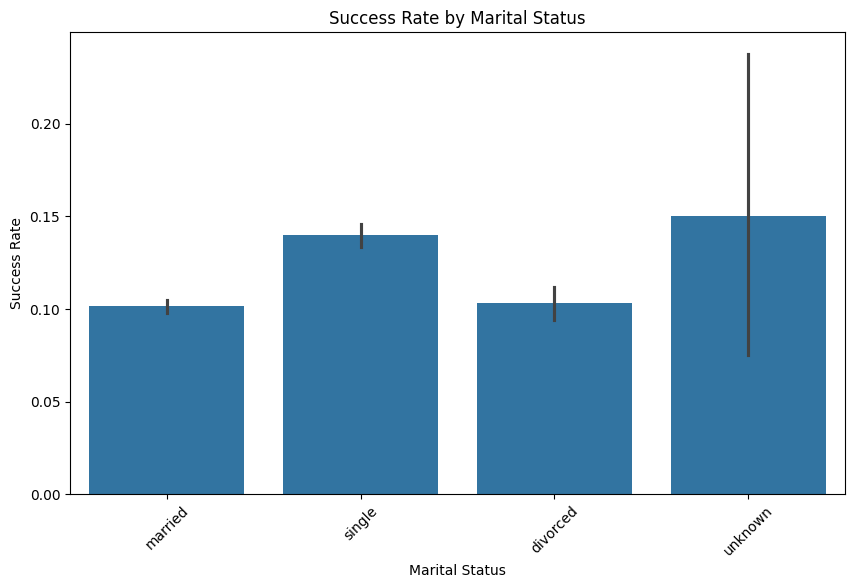

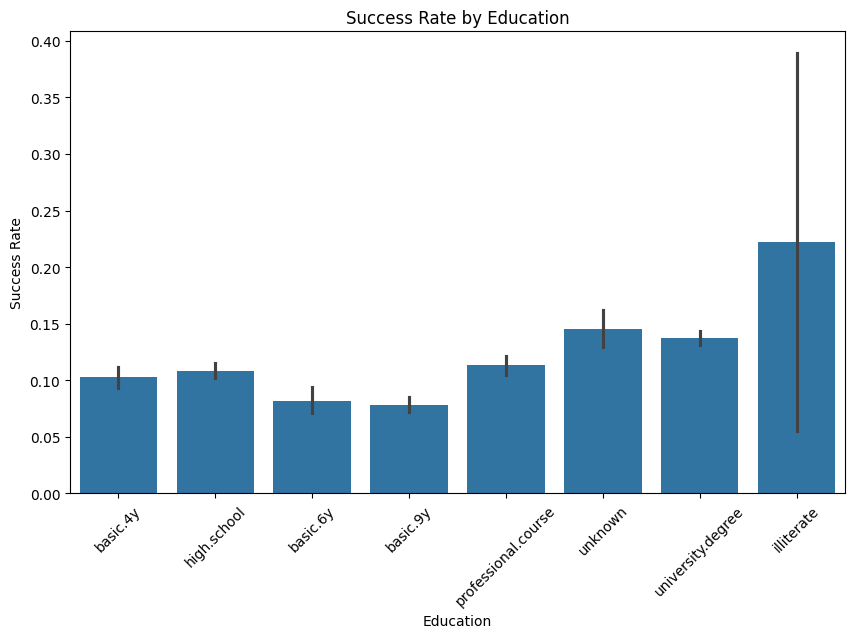

In [43]:
from matplotlib import pyplot as plt
import seaborn as sns

#Demographic indicators

plt.figure(figsize=(10, 6))
sns.histplot(x=df['age'], hue=df['y'], multiple='fill')
plt.title('Success Rate by Age')
plt.xlabel('Age')
plt.ylabel('Success Rate (Proportion)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=df['job'], y=df['y_binary'])
plt.title('Success Rate by Job')
plt.xlabel('Job')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=df['marital'], y=df['y_binary'])
plt.title('Success Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=df['education'], y=df['y_binary'])
plt.title('Success Rate by Education')
plt.xlabel('Education')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.show()

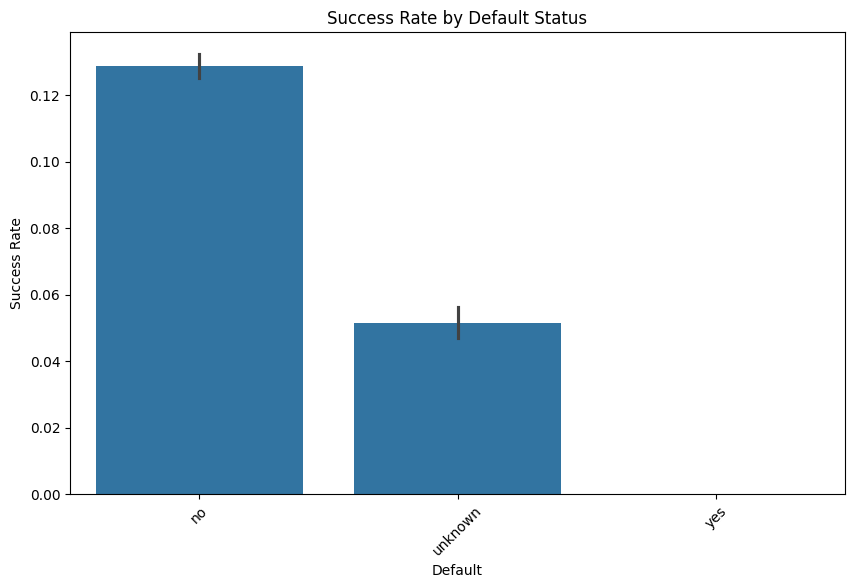

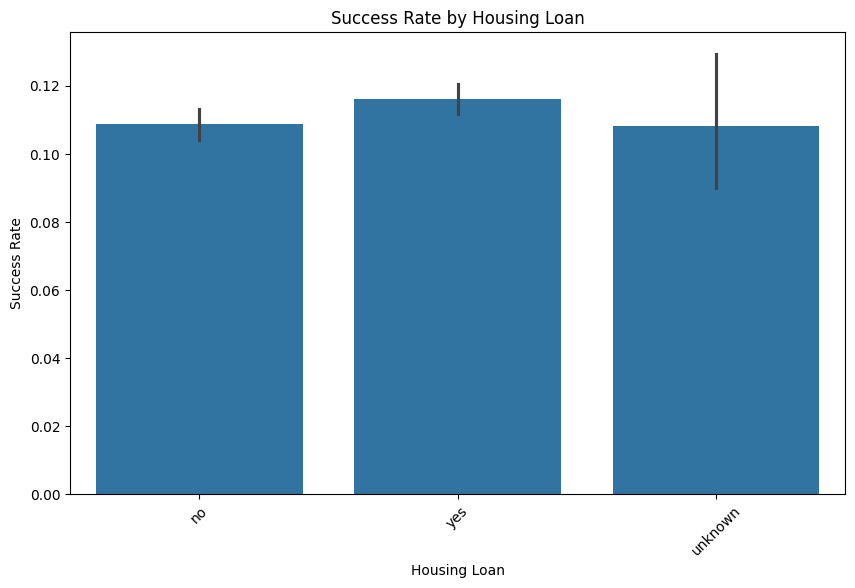

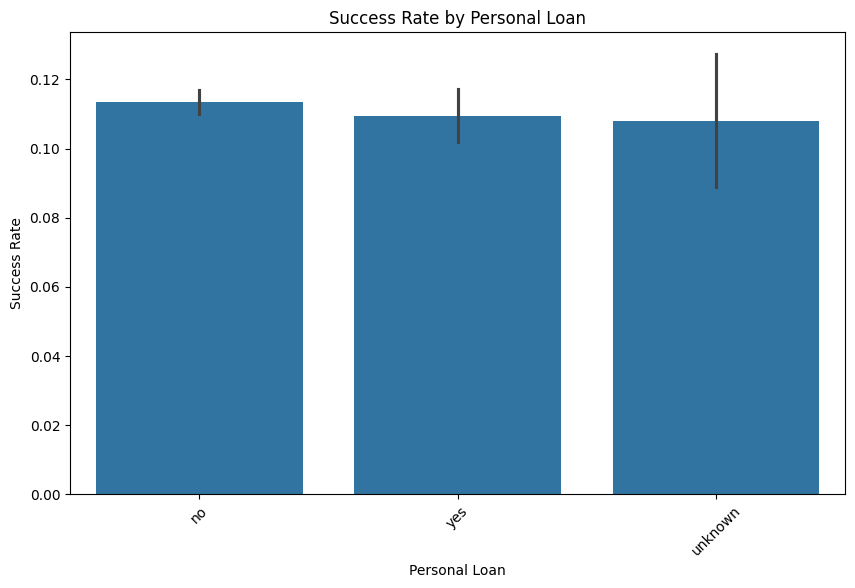

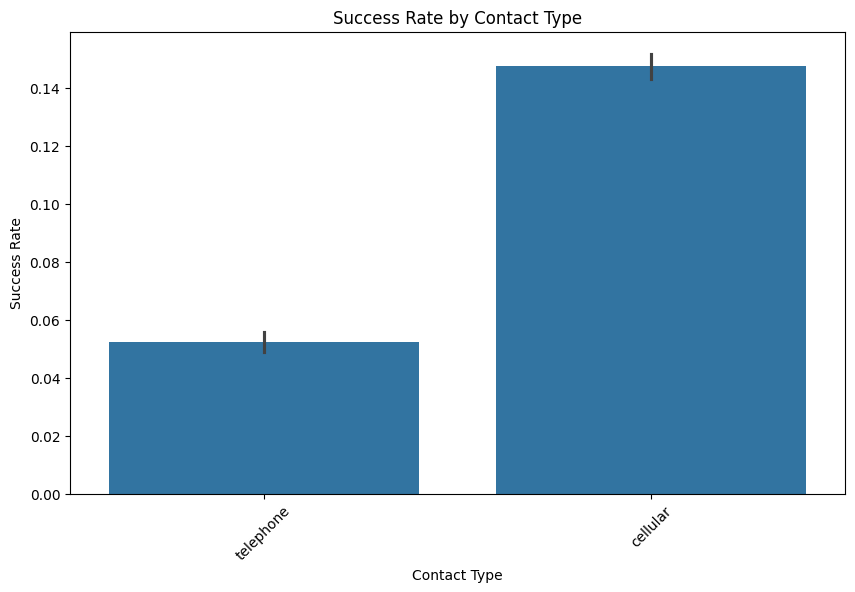

In [44]:
#individual financial health indicators

plt.figure(figsize=(10, 6))
sns.barplot(x=df['default'], y=df['y_binary'])
plt.title('Success Rate by Default Status')
plt.xlabel('Default')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=df['housing'], y=df['y_binary'])
plt.title('Success Rate by Housing Loan')
plt.xlabel('Housing Loan')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=df['loan'], y=df['y_binary'])
plt.title('Success Rate by Personal Loan')
plt.xlabel('Personal Loan')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=df['contact'], y=df['y_binary'])
plt.title('Success Rate by Contact Type')
plt.xlabel('Contact Type')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.show()

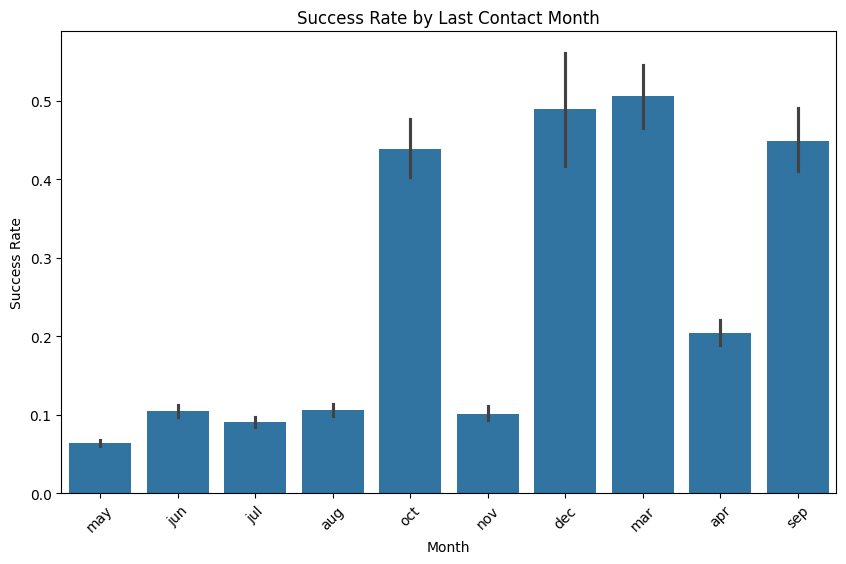

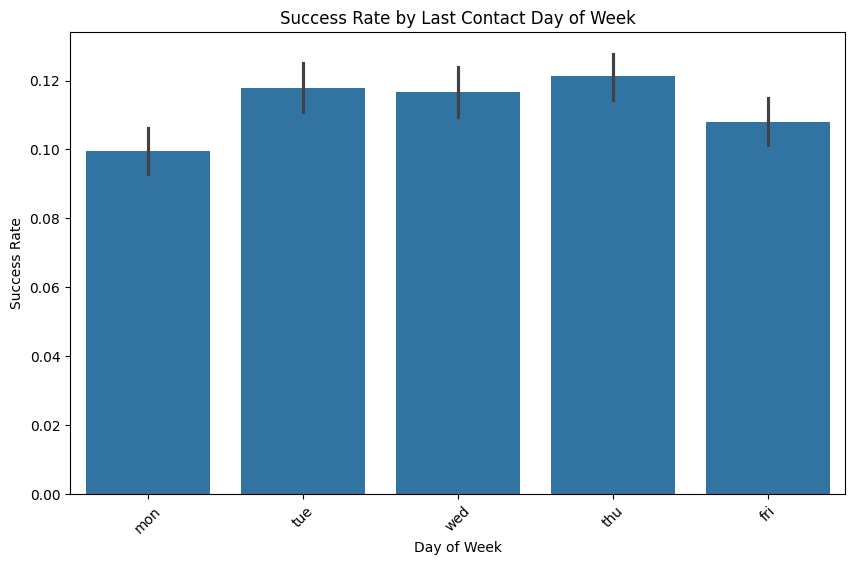

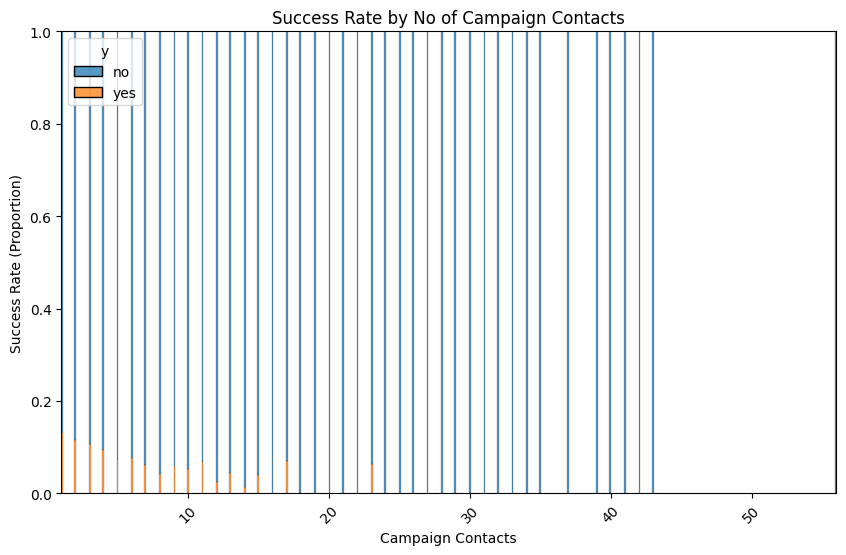

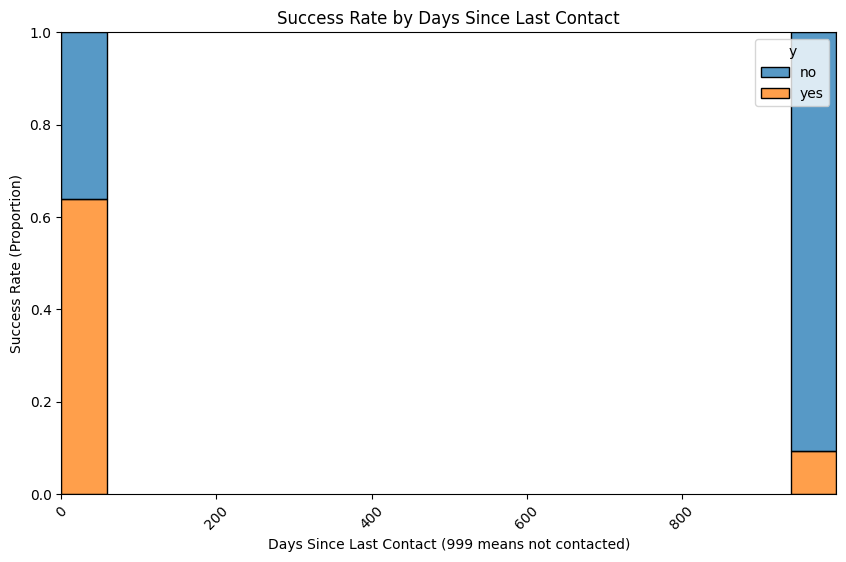

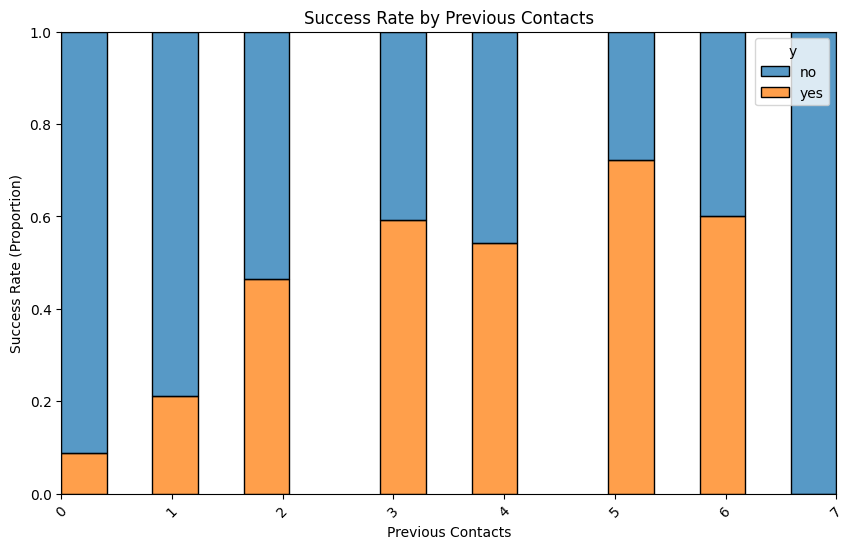

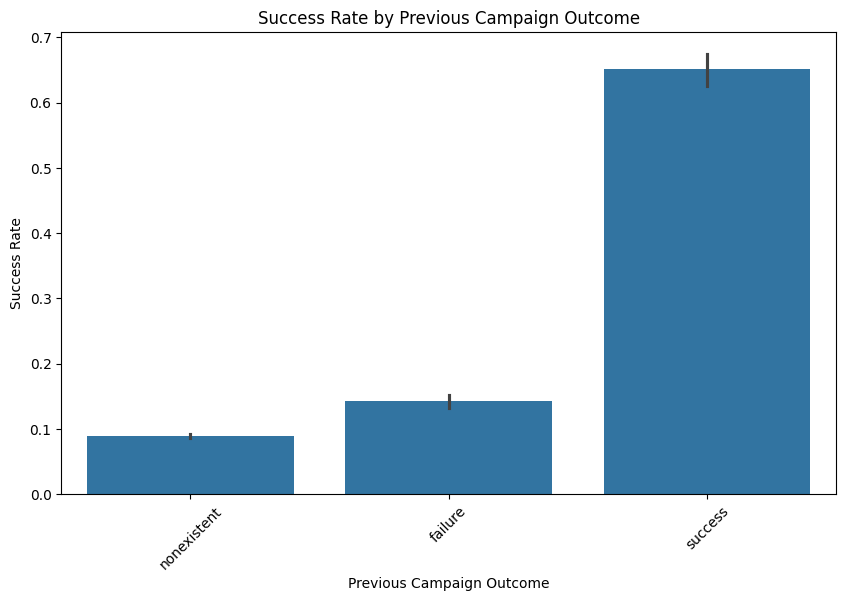

In [45]:
#previous campaign indicators

plt.figure(figsize=(10, 6))
sns.barplot(x=df['month'], y=df['y_binary'])
plt.title('Success Rate by Last Contact Month')
plt.xlabel('Month')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=df['day_of_week'], y=df['y_binary'])
plt.title('Success Rate by Last Contact Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(x=df['campaign'], hue=df['y'], multiple='fill')
plt.title('Success Rate by No of Campaign Contacts')
plt.xlabel('Campaign Contacts')
plt.ylabel('Success Rate (Proportion)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(x=df['pdays'], hue=df['y'], multiple='fill')
plt.title('Success Rate by Days Since Last Contact')
plt.xlabel('Days Since Last Contact (999 means not contacted)')
plt.ylabel('Success Rate (Proportion)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(x=df['previous'], hue=df['y'], multiple='fill')
plt.title('Success Rate by Previous Contacts')
plt.xlabel('Previous Contacts')
plt.ylabel('Success Rate (Proportion)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x=df['poutcome'], y=df['y_binary'])
plt.title('Success Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Success Rate')
plt.xticks(rotation=45)
plt.show()

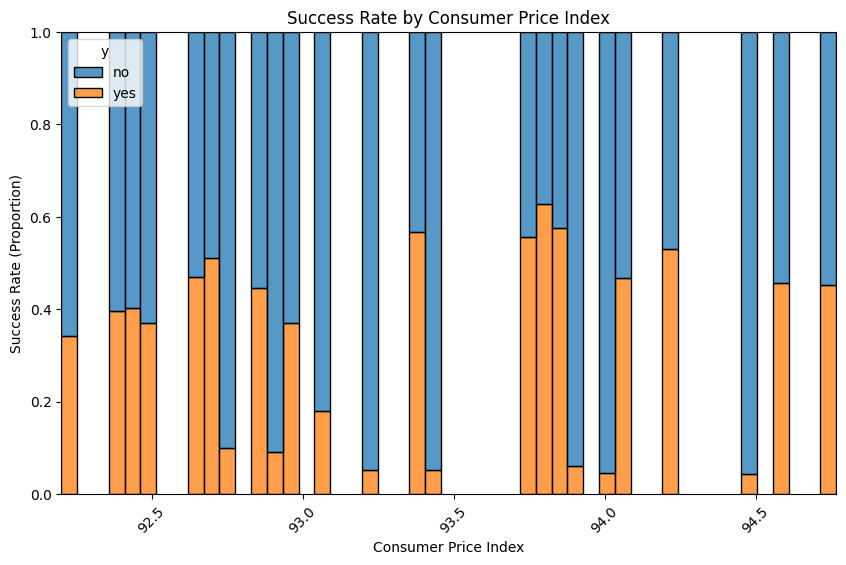

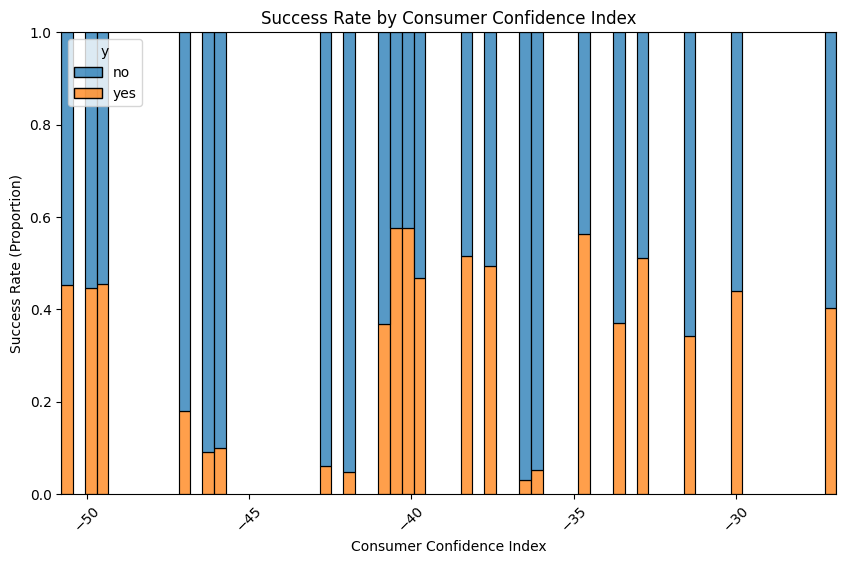

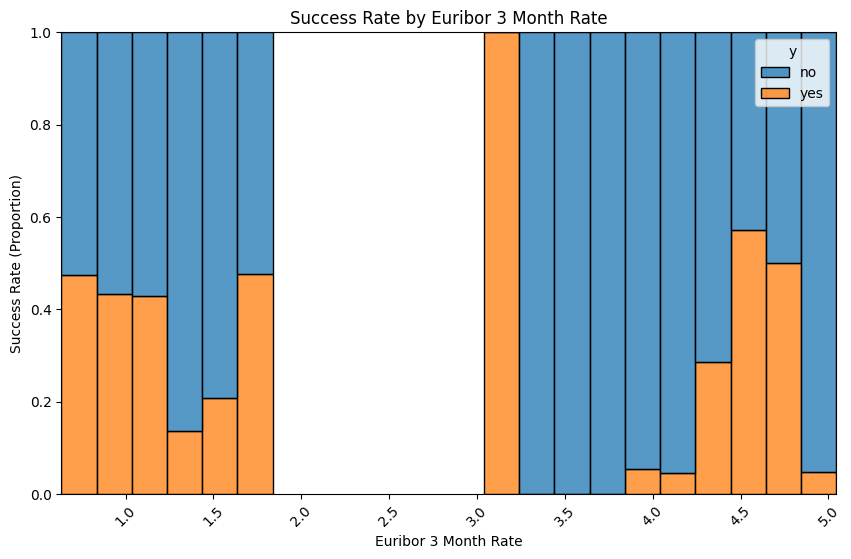

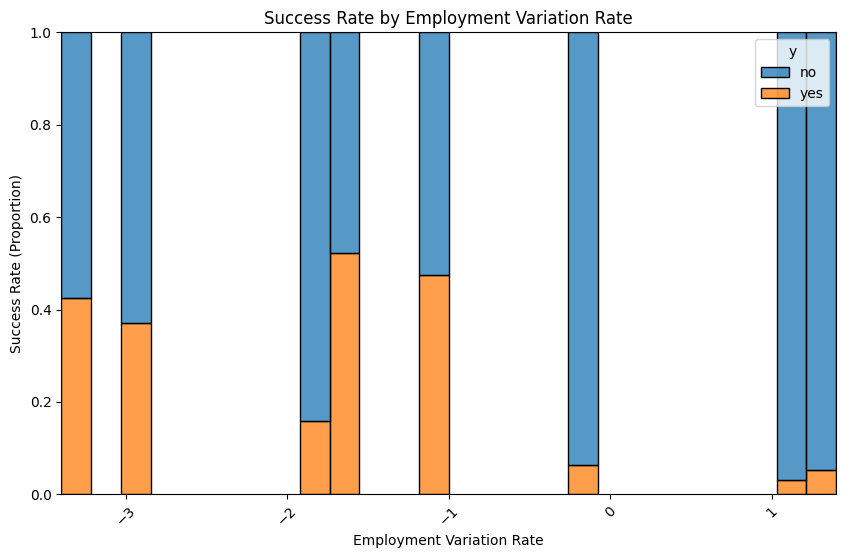

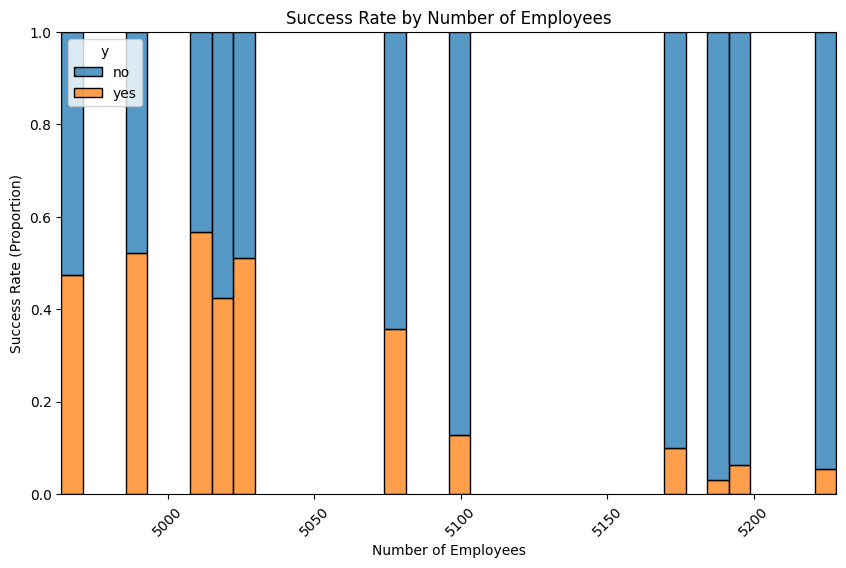

In [46]:
#global economic indicators

#Higher CPI -> higher TD rate -> pushes customer to go for TD
plt.figure(figsize=(10, 6))
sns.histplot(x=df['cons.price.idx'], hue=df['y'], multiple='fill')
plt.title('Success Rate by Consumer Price Index')
plt.xlabel('Consumer Price Index')
plt.ylabel('Success Rate (Proportion)')
plt.xticks(rotation=45)
plt.show()

#cons.conf.idx drop-> higher TD rate -> pushes customer to go for TD
plt.figure(figsize=(10, 6))
sns.histplot(x=df['cons.conf.idx'], hue=df['y'], multiple='fill')
plt.title('Success Rate by Consumer Confidence Index')
plt.xlabel('Consumer Confidence Index')
plt.ylabel('Success Rate (Proportion)')
plt.xticks(rotation=45)
plt.show()

#Euribor rises -> higher TD rate -> pushes customer to go for TD
plt.figure(figsize=(10, 6))
sns.histplot(x=df['euribor3m'], hue=df['y'], multiple='fill')
plt.title('Success Rate by Euribor 3 Month Rate')
plt.xlabel('Euribor 3 Month Rate')
plt.ylabel('Success Rate (Proportion)')
plt.xticks(rotation=45)
plt.show()

#emp.var.rate and nr.employed rises -> pushes customer away from TD
plt.figure(figsize=(10, 6))
sns.histplot(x=df['emp.var.rate'], hue=df['y'], multiple='fill')
plt.title('Success Rate by Employment Variation Rate')
plt.xlabel('Employment Variation Rate')
plt.ylabel('Success Rate (Proportion)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(x=df['nr.employed'], hue=df['y'], multiple='fill')
plt.title('Success Rate by Number of Employees')
plt.xlabel('Number of Employees')
plt.ylabel('Success Rate (Proportion)')
plt.xticks(rotation=45)
plt.show()

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

### Build a classification model which can predict which customer will accept the marketing offer.

Create a baseline model, and also then use the different classification techniques, compare their performance and find the highest performing model.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [47]:
from sklearn.preprocessing import TargetEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer


df_target = df['y']
le = LabelEncoder()
df_target = le.fit_transform(df_target)


In [48]:
X = df.drop(columns=['y', 'duration'])
y = df_target

# 2. Map Ordinal Columns Manually to preserve their inherent order
education_mapping = {
    'illiterate': 0, 'basic.4y': 1, 'basic.6y': 2, 'basic.9y': 3,
    'high.school': 4, 'professional.course': 5, 'university.degree': 6, 'unknown': -1
}
month_mapping = {
    'mar': 3, 'apr': 4, 'may': 5, 'jun': 6, 'jul': 7,
    'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}
day_mapping = {
    'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4, 'fri': 5
}

X['education'] = X['education'].map(education_mapping)
X['month'] = X['month'].map(month_mapping)
X['day_of_week'] = X['day_of_week'].map(day_mapping)

# 3. One-Hot Encode the remaining nominal categorical features
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, shuffle=True, stratify=y)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

### Baseline Model: Majority Class Prediction

A common and simple baseline for classification tasks, especially with imbalanced classes, is to predict the majority class for all instances. The accuracy of this baseline model is simply the proportion of the majority class in the dataset.

In [55]:
# Calculate the frequency of each class in the target variable
class_counts = df['y'].value_counts(normalize=True)

# The baseline accuracy is the proportion of the majority class
baseline_accuracy = class_counts.max()

print(f"Class distribution:\n{class_counts}")
print(f"\nBaseline accuracy (by predicting the majority class 'no'): {baseline_accuracy:.4f}")

Class distribution:
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

Baseline accuracy (by predicting the majority class 'no'): 0.8873


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from time import time

# Create a pipeline with a scaler and a logistic regression model

lr_pipe = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(random_state=42))])
start_time = time()
lr_pipe.fit(X_train, y_train)
end_time = time()
lr_train_time = end_time - start_time


### Problem 9: Score the Model

What is the accuracy of your model?

In [57]:
train_preds = lr_pipe.predict(X_train)
test_preds = lr_pipe.predict(X_test)
lr_train_acc = accuracy_score(y_train, train_preds)
lr_test_acc = accuracy_score(y_test, test_preds)

lr_prec = precision_score(y_test, test_preds)
lr_recall = recall_score(y_test, test_preds)
lr_f1 = f1_score(y_test, test_preds)

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [59]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from time import time

# Create a pipeline with a scaler and a KNN\\    model

knn_pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])


start_time = time()
knn_pipe.fit(X_train, y_train)
end_time = time()
knn_train_time = end_time - start_time
knn_preds = knn_pipe.predict(X_train)
knn_train_acc = accuracy_score(y_train, knn_preds)

knn_preds = knn_pipe.predict(X_test)
knn_test_acc = accuracy_score(y_test, knn_preds)


dt_pipe = Pipeline([('scaler', StandardScaler()), ('tree', DecisionTreeClassifier(random_state=42))])

start_time = time()
dt_pipe.fit(X_train, y_train)
end_time = time()
dt_train_time = end_time - start_time
dt_preds = dt_pipe.predict(X_train)
dt_train_acc = accuracy_score(y_train, dt_preds)

dt_preds = dt_pipe.predict(X_test)
dt_test_acc = accuracy_score(y_test, dt_preds)


svm_pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(random_state=42))])

start_time = time()
svm_pipe.fit(X_train, y_train)
end_time = time()
svm_train_time = end_time - start_time
svm_preds = svm_pipe.predict(X_train)
svm_train_acc = accuracy_score(y_train, svm_preds)

svm_preds = svm_pipe.predict(X_test)
svm_test_acc = accuracy_score(y_test, svm_preds)

knn_prec = precision_score(y_test, knn_preds)
dt_prec = precision_score(y_test, dt_preds)
svm_prec = precision_score(y_test, svm_preds)

knn_recall = recall_score(y_test, knn_preds)
dt_recall = recall_score(y_test, dt_preds)
svm_recall = recall_score(y_test, svm_preds)

knn_f1 = f1_score(y_test, knn_preds)
dt_f1 = f1_score(y_test, dt_preds)
svm_f1 = f1_score(y_test, svm_preds)

df_models = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM'],
    'Train Time': [lr_train_time, knn_train_time, dt_train_time, svm_train_time],
    'Train Accuracy': [lr_train_acc, knn_train_acc, dt_train_acc, svm_train_acc],
    'Test Accuracy': [lr_test_acc, knn_test_acc, dt_test_acc, svm_test_acc],
    'Precision': [lr_prec, knn_prec, dt_prec, svm_prec],
    'Recall': [lr_recall, knn_recall, dt_recall, svm_recall],
    'F1': [lr_f1, knn_f1, dt_f1, svm_f1]
})

df_models.set_index('Model', inplace=True)
df_models

,Train Time,Train Accuracy,Test Accuracy,Precision,Recall,F1
Model,,,,,,
Logistic Regression,0.136382,1.000000,1.000000,1.000000,1.000000,1.000000
KNN,0.057780,0.997101,0.995145,0.993266,0.963423,0.978117
Decision Tree,0.073671,1.000000,1.000000,1.000000,1.000000,1.000000
SVM,2.830977,1.000000,0.999853,0.999347,0.999347,0.999347


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [60]:
from sklearn.model_selection import GridSearchCV

# Define parameter grids
lr_param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__solver': ['liblinear', 'lbfgs']
}

knn_param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance']
}

tree_param_grid = {
    'tree__max_depth': [None, 3, 5, 7, 10],
    'tree__min_samples_split': [2, 5, 10]
}

svc_param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['linear', 'rbf', 'poly'],
    'svc__gamma': ['scale', 'auto']
}

models = {
    'Logistic Regression': (lr_pipe, lr_param_grid),
    'KNeighbors Classifier': (knn_pipe, knn_param_grid),
    'Decision Tree Classifier': (dt_pipe, tree_param_grid),
    'Support Vector Classifier': (svm_pipe, svc_param_grid)
}

results = {}

for name, (pipeline, param_grid) in models.items():
    print(f"Running GridSearchCV for {name}...")
    grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    results[name] = grid_search.best_estimator_
    print(f"Finished {name}.")
    print(f"Best parameters: {grid_search.best_params_}")
    # Corrected: Access 'mean_fit_time' from cv_results_ dictionary
    print(f"Best time (mean_fit_time): {grid_search.cv_results_['mean_fit_time'].mean():.4f} seconds\n")
    print(f"Best score: {grid_search.best_score_}\n")

Running GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Finished Logistic Regression.
Best parameters: {'lr__C': 0.01, 'lr__solver': 'liblinear'}
Best time (mean_fit_time): 0.1844 seconds

Best score: 1.0

Running GridSearchCV for KNeighbors Classifier...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Finished KNeighbors Classifier.
Best parameters: {'knn__n_neighbors': 3, 'knn__weights': 'distance'}
Best time (mean_fit_time): 0.0750 seconds

Best score: 0.993658271425983

Running GridSearchCV for Decision Tree Classifier...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Finished Decision Tree Classifier.
Best parameters: {'tree__max_depth': None, 'tree__min_samples_split': 2}
Best time (mean_fit_time): 0.1027 seconds

Best score: 1.0

Running GridSearchCV for Support Vector Classifier...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Finished Support Vector Classifier.
Best parameters: {'svc_

##### Questions